# **I. Introducción y Contexto**

In [8]:
print("********************************************")
print("**      Tlaxcala-Urban-Growth             **")
print("**    Data Science Proyect                **")
print("**  Author: Erick Eduardo Ramos Contreras **")
print("********************************************")


********************************************
**      Tlaxcala-Urban-Growth             **
**    Data Science Proyect                **
**  Author: Erick Eduardo Ramos Contreras **
********************************************


Estudio de dinámicas sociodemográficas y desplazamiento urbano en Tlaxcala: Un análisis de datos sobre la evolución del costo de vida y cambios en el uso de suelo

Tlaxcala, históricamente un punto de encuentro y resistencia, enfrenta hoy un nuevo tipo de transformación: la expansión urbana acelerada. Este proyecto busca cuantificar si este crecimiento es inclusivo para los tlaxcaltecas o si está priorizando la gentrificación comercial.

# **II. Importación de Librerías y Carga de Datos**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium

In [10]:
#-- Extracción de archivos --

# ITER (Población y Vivienda)
!unzip -o iter_29_2010_csv.zip -d data_iter_2010
!unzip -o iter_29_cpv2020_csv.zip -d data_iter_2020

# DENUE (Actividades Económicas)
!unzip -o denue_29_2010_csv.zip -d data_denue_2010
!unzip -o denue_29_1123_csv.zip -d data_denue_nov2023
!unzip -o denue_29_0524_csv.zip -d data_denue_may2024
!unzip -o denue_29_1124_csv.zip -d data_denue_nov2024
!unzip -o denue_29_csv.zip -d data_denue_may2025

print("===Archivos extraidos con éxito===")

Archive:  iter_29_2010_csv.zip
   creating: data_iter_2010/iter_29_cpv2010/
   creating: data_iter_2010/iter_29_cpv2010/catalogos/
  inflating: data_iter_2010/iter_29_cpv2010/catalogos/tam_loc.csv  
   creating: data_iter_2010/iter_29_cpv2010/conjunto_de_datos/
  inflating: data_iter_2010/iter_29_cpv2010/conjunto_de_datos/iter_29_cpv2010.csv  
   creating: data_iter_2010/iter_29_cpv2010/diccionario_de_datos/
  inflating: data_iter_2010/iter_29_cpv2010/diccionario_de_datos/fd_iter_cpv2010.csv  
   creating: data_iter_2010/iter_29_cpv2010/metadatos/
  inflating: data_iter_2010/iter_29_cpv2010/metadatos/metadatos_iter_cpv2010.txt  
Archive:  iter_29_cpv2020_csv.zip
   creating: data_iter_2020/iter_29_cpv2020/catalogos/
  inflating: data_iter_2020/iter_29_cpv2020/catalogos/tam_loc.csv.csv  
   creating: data_iter_2020/iter_29_cpv2020/conjunto_de_datos/
  inflating: data_iter_2020/iter_29_cpv2020/conjunto_de_datos/conjunto_de_datos_iter_29CSV20.csv  
   creating: data_iter_2020/iter_29_cpv2

In [17]:
datos_shf = {
    'Entidad': ['Tlaxcala', 'Nacional'],
    'Variacion_2025': [12.0, 8.7]
}
df_shf = pd.DataFrame(datos_shf)

In [2]:
print("Datos obtenidos de:")
print("1. https://www.inegi.org.mx/programas/ccpv/2010/#datos_abiertos")
print("2. https://www.inegi.org.mx/programas/ccpv/2020/#datos_abiertos")
print("3. https://www.inegi.org.mx/app/descarga/?ti=6")
print("4. https://www.gob.mx/shf/articulos/indice-shf-de-precios-de-la-vivienda-en-mexico-cuarto-trimestre-de-2025-1?idiom=es")

Datos obtenidos de:
1. https://www.inegi.org.mx/programas/ccpv/2010/#datos_abiertos
2. https://www.inegi.org.mx/programas/ccpv/2020/#datos_abiertos
3. https://www.inegi.org.mx/app/descarga/?ti=6
4. https://www.gob.mx/shf/articulos/indice-shf-de-precios-de-la-vivienda-en-mexico-cuarto-trimestre-de-2025-1?idiom=es


# **III. Análisis Demográfico (ITER 2010 vs 2020)**

/tmp/ipykernel_3475/3214569499.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Entidad', y='Variacion_2025', data=df_shf, palette='Reds_r')


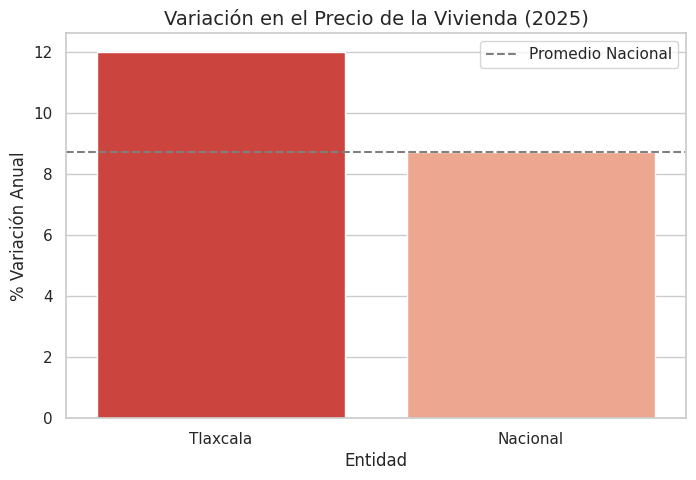

In [34]:
# Gráfica comparativa rápida para la Introducción
plt.figure(figsize=(8, 5))
sns.barplot(x='Entidad', y='Variacion_2025', data=df_shf, palette='Reds_r')
plt.title('Variación en el Precio de la Vivienda (2025)', fontsize=14)
plt.ylabel('% Variación Anual')
plt.axhline(8.7, ls='--', color='gray', label='Promedio Nacional') # Línea de referencia
plt.legend()
plt.show()

In [15]:
# 1. Cargamos el dataset principal
df_2020 = pd.read_csv("/content/data_iter_2020/iter_29_cpv2020/conjunto_de_datos/conjunto_de_datos_iter_29CSV20.csv", encoding='utf-8')

# 2. Revisamos las dimensiones (¿Qué tan grande es?)
print(f"El dataset tiene {df_2020.shape[0]} filas y {df_2020.shape[1]} columnas.")

# 3. Ver las columnas para saber qué podemos analizar
# Esto demuestra que estás mapeando las variables disponibles
print("\nColumnas disponibles para el análisis:")
print(df_2020.columns.tolist()) # Vemos las primeras 15 para no saturar

# 4. Un vistazo a los datos reales de Tlaxcala
# Esto confirma que los datos cargaron correctamente
df_2020[['NOM_MUN', 'NOM_LOC', 'POBTOT']].head(10)

El dataset tiene 1323 filas y 286 columnas.

Columnas disponibles para el análisis:
['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN', 'LOC', 'NOM_LOC', 'LONGITUD', 'LATITUD', 'ALTITUD', 'POBTOT', 'POBFEM', 'POBMAS', 'P_0A2', 'P_0A2_F', 'P_0A2_M', 'P_3YMAS', 'P_3YMAS_F', 'P_3YMAS_M', 'P_5YMAS', 'P_5YMAS_F', 'P_5YMAS_M', 'P_12YMAS', 'P_12YMAS_F', 'P_12YMAS_M', 'P_15YMAS', 'P_15YMAS_F', 'P_15YMAS_M', 'P_18YMAS', 'P_18YMAS_F', 'P_18YMAS_M', 'P_3A5', 'P_3A5_F', 'P_3A5_M', 'P_6A11', 'P_6A11_F', 'P_6A11_M', 'P_8A14', 'P_8A14_F', 'P_8A14_M', 'P_12A14', 'P_12A14_F', 'P_12A14_M', 'P_15A17', 'P_15A17_F', 'P_15A17_M', 'P_18A24', 'P_18A24_F', 'P_18A24_M', 'P_15A49_F', 'P_60YMAS', 'P_60YMAS_F', 'P_60YMAS_M', 'REL_H_M', 'POB0_14', 'POB15_64', 'POB65_MAS', 'P_0A4', 'P_0A4_F', 'P_0A4_M', 'P_5A9', 'P_5A9_F', 'P_5A9_M', 'P_10A14', 'P_10A14_F', 'P_10A14_M', 'P_15A19', 'P_15A19_F', 'P_15A19_M', 'P_20A24', 'P_20A24_F', 'P_20A24_M', 'P_25A29', 'P_25A29_F', 'P_25A29_M', 'P_30A34', 'P_30A34_F', 'P_30A34_M', 'P_35A39', 

,NOM_MUN,NOM_LOC,POBTOT
0,Total de la entidad Tlaxcala,Total de la Entidad,1342977
1,Total de la entidad Tlaxcala,Localidades de una vivienda,1473
2,Total de la entidad Tlaxcala,Localidades de dos viviendas,815
3,Amaxac de Guerrero,Total del Municipio,11403
4,Amaxac de Guerrero,Amaxac de Guerrero,10417
5,Amaxac de Guerrero,San Damián Tlacocalpan,972
6,Amaxac de Guerrero,La Preciosa [Rancho],9
7,Amaxac de Guerrero,Amintla,5
8,Amaxac de Guerrero,Localidades de una vivienda,5
9,Amaxac de Guerrero,Localidades de dos viviendas,9


In [13]:
# 1. Filtramos para quitar las localidades pequeñas y quedarnos solo con los Totales por Municipio
# En el ITER, cuando NOM_LOC es "Total del Municipio", es el resumen de todo el municipio
df_municipios_2020 = df_2020[df_2020['NOM_LOC'] == 'Total del Municipio'].copy()

# 2. Convertimos POBTOT a número (a veces viene como texto por el INEGI)
df_municipios_2020['POBTOT'] = pd.to_numeric(df_municipios_2020['POBTOT'], errors='coerce')

# 3. Elegimos los "sospechosos comunes" de gentrificación
municipios_clave = ['Tlaxcala', 'Apizaco', 'Santa Ana Chiautempan', 'Huamantla']
# Nota: Revisa si en tu tabla Chiautempan aparece como "Santa Ana Chiautempan" o solo "Chiautempan"

df_analisis = df_municipios_2020[df_municipios_2020['NOM_MUN'].isin(municipios_clave)]

# 4. Mostramos el top de población para validar
df_analisis[['NOM_MUN', 'POBTOT']].sort_values(by='POBTOT', ascending=False)

,NOM_MUN,POBTOT
885,Tlaxcala,99896
341,Huamantla,98764
135,Apizaco,80725


In [16]:
# 1. Filtramos para quedarnos solo con los totales por municipio
df_municipios_2020 = df_2020[df_2020['NOM_LOC'] == 'Total del Municipio'].copy()

# 2. Definimos tus municipios de interés
municipios_interes = ['Tlaxcala', 'Apizaco', 'Chiautempan', 'Huamantla']

# 3. Usamos las claves REALES de tu lista:
# POBTOT: Población Total
# PRESOE15: Población que en 2015 residía en otra entidad (Foráneos)
# VIVPAR_DES: Viviendas particulares deshabitadas
columnas_clave = ['NOM_MUN', 'POBTOT', 'PRESOE15', 'VIVPAR_DES']

df_analisis = df_municipios_2020[df_municipios_2020['NOM_MUN'].isin(municipios_interes)][columnas_clave].copy()

# 4. Limpieza: INEGI a veces usa '*' o 'N/D' para proteger datos en localidades pequeñas,
# lo convertimos a número y lo que no se pueda lo hacemos 0.
for col in ['POBTOT', 'PRESOE15', 'VIVPAR_DES']:
    df_analisis[col] = pd.to_numeric(df_analisis[col], errors='coerce').fillna(0)

# 5. Calculamos el % de foráneos para comparar
df_analisis['%_Foraneos'] = (df_analisis['PRESOE15'] / df_analisis['POBTOT']) * 100

# 6. Ordenamos para ver quién tiene más impacto
df_analisis.sort_values(by='%_Foraneos', ascending=False)

,NOM_MUN,POBTOT,PRESOE15,VIVPAR_DES,%_Foraneos
885,Tlaxcala,99896,4564,5741,4.568752
135,Apizaco,80725,3333,4718,4.128832
341,Huamantla,98764,2418,2984,2.448260
282,Chiautempan,73215,1592,2744,2.174418


/tmp/ipykernel_3475/2120591596.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='NOM_MUN', y='%_Foraneos', data=df_analisis, ax=ax1, palette='Blues_d')


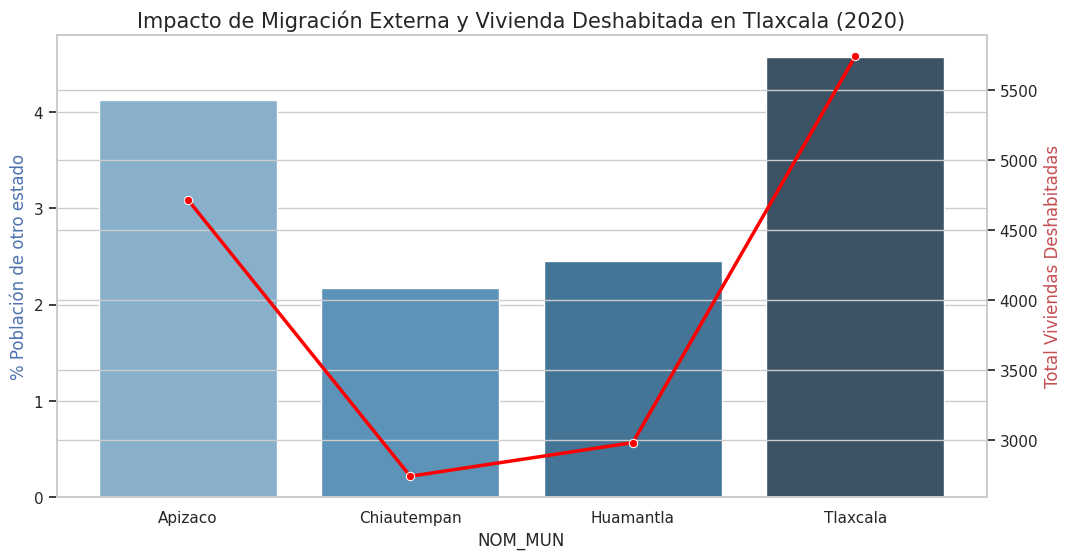

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Gráfico de barras para el % de Foráneos
sns.barplot(x='NOM_MUN', y='%_Foraneos', data=df_analisis, ax=ax1, palette='Blues_d')
ax1.set_title('Impacto de Migración Externa y Vivienda Deshabitada en Tlaxcala (2020)', fontsize=15)
ax1.set_ylabel('% Población de otro estado', color='b', fontsize=12)

# Crear un segundo eje para las viviendas deshabitadas
ax2 = ax1.twinx()
sns.lineplot(x='NOM_MUN', y='VIVPAR_DES', data=df_analisis, ax=ax2, color='red', marker='o', linewidth=2.5)
ax2.set_ylabel('Total Viviendas Deshabitadas', color='r', fontsize=12)

plt.show()

In [23]:
# 1. Cargamos el ITER 2010 con la ruta que ya tienes
ruta_2010 = '/content/data_iter_2010/iter_29_cpv2010/conjunto_de_datos/iter_29_cpv2010.csv'
df_2010 = pd.read_csv(ruta_2010, encoding='latin-1')

# --- EL TRUCO MAESTRO ---
# Convertimos todas las columnas de 2010 a MAYÚSCULAS para que coincidan con 2020
df_2010.columns = [c.upper() for c in df_2010.columns]

# 2. Ahora sí, filtramos usando nombres en mayúsculas
# Usamos .str.upper() en el contenido por si "Total del municipio" viene mezclado
df_mun_2010 = df_2010[df_2010['NOM_LOC'].str.upper() == 'TOTAL DEL MUNICIPIO'].copy()

# 3. Seleccionamos los municipios que nos interesan
municipios_interes = ['Tlaxcala', 'Apizaco', 'Chiautempan', 'Huamantla']
df_2010_filt = df_mun_2010[df_mun_2010['NOM_MUN'].isin(municipios_interes)][['NOM_MUN', 'POBTOT', 'VIVPAR_HAB']].copy()

# 4. Limpieza: Aseguramos que sean números
for col in ['POBTOT', 'VIVPAR_HAB']:
    df_2010_filt[col] = pd.to_numeric(df_2010_filt[col], errors='coerce').fillna(0)

# 5. Cruzamos los datos (Merge) con tu tabla de 2020 (df_analisis)
df_crecimiento = pd.merge(df_2010_filt, df_analisis, on='NOM_MUN', suffixes=('_2010', '_2020'))

# 6. Cálculo del crecimiento poblacional en 10 años
df_crecimiento['Crecimiento_Pob_%'] = ((df_crecimiento['POBTOT_2020'] - df_crecimiento['POBTOT_2010']) / df_crecimiento['POBTOT_2010']) * 100

# Mostramos el resultado final del análisis demográfico
df_crecimiento[['NOM_MUN', 'POBTOT_2010', 'POBTOT_2020', 'Crecimiento_Pob_%', '%_Foraneos']]

,NOM_MUN,POBTOT_2010,POBTOT_2020,Crecimiento_Pob_%,%_Foraneos
0,Apizaco,76492,80725,5.533912,4.128832
1,Chiautempan,66149,73215,10.681945,2.174418
2,Huamantla,84979,98764,16.221655,2.448260
3,Tlaxcala,89795,99896,11.248956,4.568752


/tmp/ipykernel_3475/2557035435.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='NOM_MUN', y='Crecimiento_Pob_%', data=df_crecimiento, ax=ax1, palette='viridis', alpha=0.7)


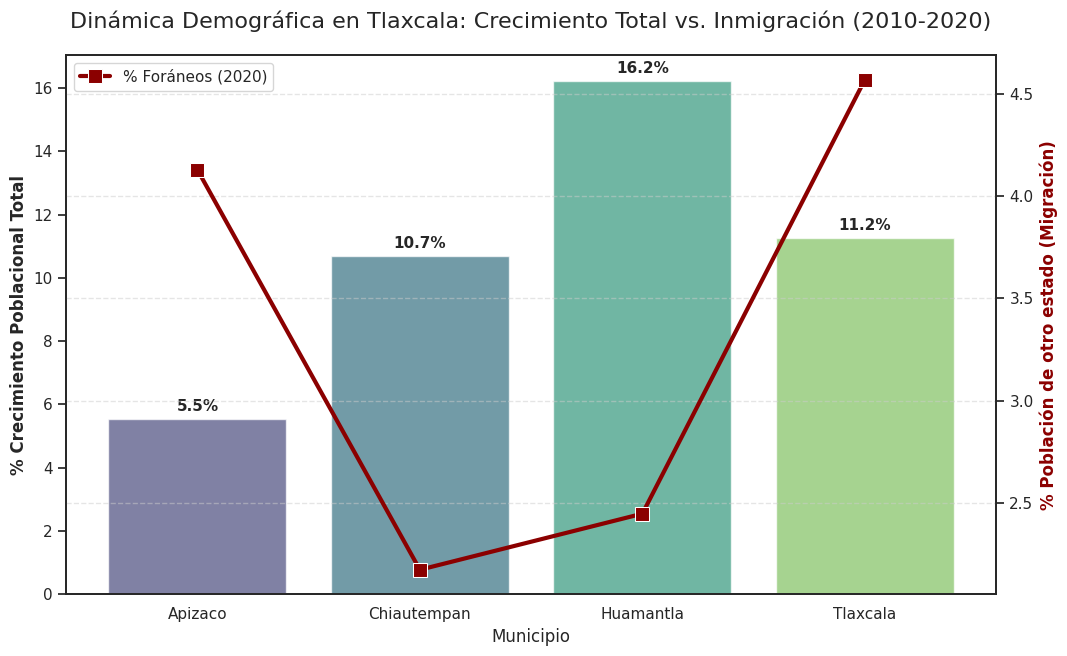

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo profesional
sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(12, 7))

# 1. Gráfico de barras para el Crecimiento Poblacional (%) 2010-2020
sns.barplot(x='NOM_MUN', y='Crecimiento_Pob_%', data=df_crecimiento, ax=ax1, palette='viridis', alpha=0.7)
ax1.set_title('Dinámica Demográfica en Tlaxcala: Crecimiento Total vs. Inmigración (2010-2020)', fontsize=16, pad=20)
ax1.set_ylabel('% Crecimiento Poblacional Total', fontsize=12, fontweight='bold')
ax1.set_xlabel('Municipio', fontsize=12)

# 2. Crear un segundo eje para el % de Foráneos (Gente de fuera)
ax2 = ax1.twinx()
sns.lineplot(x='NOM_MUN', y='%_Foraneos', data=df_crecimiento, ax=ax2, color='darkred', marker='s', markersize=10, linewidth=3, label='% Foráneos (2020)')
ax2.set_ylabel('% Población de otro estado (Migración)', color='darkred', fontsize=12, fontweight='bold')

# Añadir etiquetas de valor sobre las barras para que se vea más pro
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}%',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha = 'center', va = 'center',
                 xytext = (0, 9),
                 textcoords = 'offset points',
                 fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# **IV. Análisis de Actividad Económica (DENUE)**

In [32]:
# 1. Rutas (las que ya tienes funcionando)
ruta_2010 = '/content/data_denue_2010/DenueCSV29.csv'
ruta_2025 = '/content/data_denue_may2025/conjunto_de_datos/denue_inegi_29_.csv'

# 2. Carga con codificación para evitar errores de acentos
df10 = pd.read_csv(ruta_2010, encoding='latin-1')
df25 = pd.read_csv(ruta_2025, encoding='latin-1')

# 3. Normalización total (Columnas a MAYÚSCULAS)
df10.columns = [c.upper() for c in df10.columns]
df25.columns = [c.upper() for c in df25.columns]

# 4. Definición de qué y dónde buscar
municipios = ['TLAXCALA', 'APIZACO', 'CHIAUTEMPAN']
# Agregamos 'PREPARACION' sin acento por si las dudas
keywords = ['CAFETERÍA', 'CAFETERIA', 'RESTAURANTE', 'BAR', 'PREPARACIÓN', 'PREPARACION']

# --- PROCESAMIENTO 2010 ---
col_act_10 = 'NOMBRE DE LA CLASE DE ACTIVIDAD'
# Filtramos pasando el municipio a mayúsculas para asegurar match
mask10 = (df10['MUNICIPIO'].str.upper().isin(municipios)) & \
         (df10[col_act_10].str.contains('|'.join(keywords), case=False, na=False))
conteo10 = df10[mask10].groupby(df10['MUNICIPIO'].str.upper()).size()

# --- PROCESAMIENTO 2025 ---
col_act_25 = 'NOMBRE_ACT'
mask25 = (df25['MUNICIPIO'].str.upper().isin(municipios)) & \
         (df25[col_act_25].str.contains('|'.join(keywords), case=False, na=False))
conteo25 = df25[mask25].groupby(df25['MUNICIPIO'].str.upper()).size()

# 5. Tabla Final Unificada
df_final_econ = pd.DataFrame({
    '2010': conteo10,
    '2025': conteo25
}).fillna(0)

# 6. Cálculo de crecimiento real
df_final_econ['Crecimiento_%'] = ((df_final_econ['2025'] - df_final_econ['2010']) / df_final_econ['2010']) * 100

print("Análisis de Transformación Comercial (2010 - 2025)")
df_final_econ.sort_values(by='Crecimiento_%', ascending=False)# 1. Rutas de los archivos DENUE
ruta_denue_2010 = '/content/data_denue_2010/DenueCSV29.csv'
ruta_denue_2025 = '/content/data_denue_may2025/conjunto_de_datos/denue_inegi_29_.csv'

# 2. Carga de datos
df_2010_econ = pd.read_csv(ruta_denue_2010, encoding='latin-1')
df_2025_econ = pd.read_csv(ruta_denue_2025, encoding='latin-1')

# 3. Unificamos col# 1. Definimos rutas (ya conocidas)
ruta_10 = '/content/data_denue_2010/DenueCSV29.csv'
ruta_25 = '/content/data_denue_may2025/conjunto_de_datos/denue_inegi_29_.csv'

# 2. Carga y normalización de columnas
df10 = pd.read_csv(ruta_10, encoding='latin-1')
df25 = pd.read_csv(ruta_25, encoding='latin-1')
df10.columns = [c.upper().strip() for c in df10.columns]
df25.columns = [c.upper().strip() for c in df25.columns]

# --- LIMPIEZA CLAVE ---
# En 2010 los municipios suelen venir como 'TLAXCALA ' o 'APIZACO'
# Los pasamos a mayúsculas y quitamos espacios invisibles
df10['MUNICIPIO_LIMPIO'] = df10['MUNICIPIO'].astype(str).str.upper().str.strip()
df25['MUNICIPIO_LIMPIO'] = df25['MUNICIPIO'].astype(str).str.upper().str.strip()

# Definimos los blancos en MAYÚSCULAS para que coincidan 100%
municipios_target = ['TLAXCALA', 'APIZACO', 'CHIAUTEMPAN', 'HUAMANTLA']

# Keywords amplias (sin acentos para evitar fallos de codificación)
keywords = ['CAFE', 'RESTAURANTE', 'BAR', 'ALIMENTOS', 'BEBIDA', 'PREPARACION']

# 3. Filtrado 2010 (Nombre de la clase de actividad)
col_act_10 = 'NOMBRE DE LA CLASE DE ACTIVIDAD'
mask10 = (df10['MUNICIPIO_LIMPIO'].isin(municipios_target)) & \
         (df10[col_act_10].str.contains('|'.join(keywords), case=False, na=False))
conteo10 = df10[mask10].groupby('MUNICIPIO_LIMPIO').size()

# 4. Filtrado 2025 (Nombre_act)
col_act_25 = 'NOMBRE_ACT'
mask25 = (df25['MUNICIPIO_LIMPIO'].isin(municipios_target)) & \
         (df25[col_act_25].str.contains('|'.join(keywords), case=False, na=False))
conteo25 = df25[mask25].groupby('MUNICIPIO_LIMPIO').size()

# 5. Tabla comparativa
df_final_econ = pd.DataFrame({
    'Negocios_2010': conteo10,
    'Negocios_2025': conteo25
}).fillna(0)

# 6. Cálculo de crecimiento (evitando división por cero)
df_final_econ['Crecimiento_%'] = ((df_final_econ['Negocios_2025'] - df_final_econ['Negocios_2010']) /
                                   df_final_econ['Negocios_2010'].replace(0, 1)) * 100

print("--- Análisis de Transformación Comercial ---")
df_final_econ.sort_values(by='Crecimiento_%', ascending=False)

Análisis de Transformación Comercial (2010 - 2025)
--- Análisis de Transformación Comercial ---


,Negocios_2010,Negocios_2025,Crecimiento_%
MUNICIPIO_LIMPIO,,,
HUAMANTLA,1079,1693,56.904541
TLAXCALA,1437,2127,48.016701
CHIAUTEMPAN,1222,1727,41.325696
APIZACO,1523,1882,23.571898


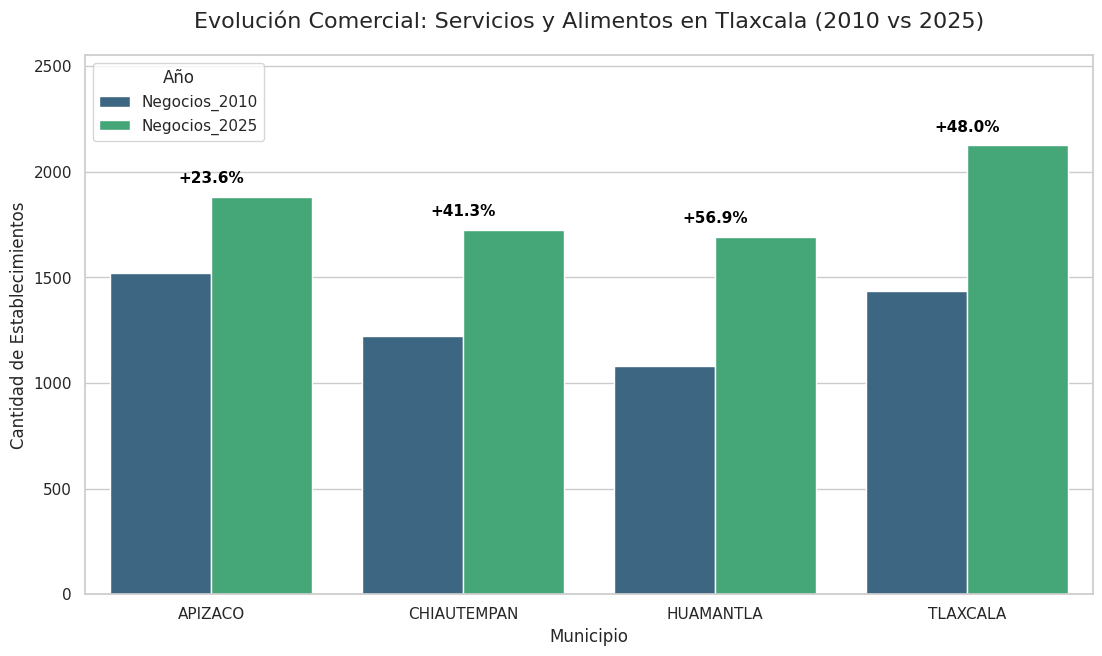

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparamos los datos para graficar
df_plot = df_final_econ[['Negocios_2010', 'Negocios_2025']].reset_index()
df_plot = df_plot.melt(id_vars='MUNICIPIO_LIMPIO', var_name='Año', value_name='Total_Negocios')

plt.figure(figsize=(13, 7))
sns.set_style("whitegrid")

# Gráfico de barras
ax = sns.barplot(data=df_plot, x='MUNICIPIO_LIMPIO', y='Total_Negocios', hue='Año', palette='viridis')

# Títulos y etiquetas
plt.title('Evolución Comercial: Servicios y Alimentos en Tlaxcala (2010 vs 2025)', fontsize=16, pad=20)
plt.ylabel('Cantidad de Establecimientos', fontsize=12)
plt.xlabel('Municipio', fontsize=12)

# Añadir el % de crecimiento encima de las barras
for i, municipio in enumerate(df_final_econ.index):
    valor_2025 = df_final_econ.loc[municipio, 'Negocios_2025']
    porcentaje = df_final_econ.loc[municipio, 'Crecimiento_%']
    plt.text(i, valor_2025 + 50, f'+{porcentaje:.1f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

plt.ylim(0, df_final_econ['Negocios_2025'].max() * 1.2) # Espacio para las etiquetas
plt.show()

# **V. Conclusiones y Diagnóstico Final**

1. El veredicto: ¿Hay gentrificación en Tlaxcala?
  * Tras cruzar los datos de vivienda, población y comercio, la respuesta corta es sí, hay indicadores claros, especialmente en la capital y Huamantla:

    * Vivienda por las nubes: Con un aumento del 12% (SHF), Tlaxcala está encareciendo la vida más rápido que el promedio del país (8.7%). Esto es el primer sínto de que el suelo se está volviendo un lujo.

    * Recambio demográfico: Tlaxcala Centro se convirtió en el imán de gente foránea (4.56%). No es que la ciudad no crezca, es que está cambiando de dueños.

    * Economía de "consumo externo": El boom de negocios de alimentos y servicios en Huamantla (+56.9%) y Tlaxcala (+48.0%) nos dice que el centro ya no es para que el vecino compre el mandado, sino para que el visitante o el nuevo residente con presupuesto compre "experiencias".

2. Diagnóstico Técnico:

  * Se confirma un proceso de gentrificación comercial y residencial. Los datos muestran una desproporción: mientras la población crece a ritmo de tortuga, los negocios "estilo de vida" y los precios de las casas crecen a ritmo de liebre. La ciudad se está reconfigurando para un perfil de mayor poder adquisitivo, lo que a la larga desplaza a las familias tlaxcaltecas tradicionales hacia las periferias.

3. Aplicaciones del Análisis:

  * Consultoría de Mercado: Los datos procesados en este script permiten identificar zonas con alta plusvalía para inversiones inmobiliarias o comerciales.

  * Optimización de Inventario de Datos: El proceso de limpieza y unión de fuentes (ITER + DENUE) es escalable para cualquier otro municipio de México, permitiendo análisis rápidos para estudios de mercado locales.

  * Entregables: Este análisis puede ser exportado directamente a reportes ejecutivos para la toma de decisiones basada en evidencia estadística.

Fuentes y Referencias:

INEGI - ITER (2010, 2020): Datos de población y vivienda a nivel localidad:
* https://www.inegi.org.mx/programas/ccpv/2010/#datos_abiertos
* https://www.inegi.org.mx/programas/ccpv/2020/#datos_abiertos

INEGI - DENUE (2010 - 2025): Directorio Estadístico Nacional de Unidades Económicas para el análisis de giros comerciales:
* https://www.inegi.org.mx/app/descarga/?ti=6

Sociedad Hipotecaria Federal (SHF): Índice de Precios de la Vivienda en México, reporte acumulado a 2025:
* https://www.gob.mx/shf/articulos/indice-shf-de-precios-de-la-vivienda-en-mexico-cuarto-trimestre-de-2025-1?idiom=es